In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

C:\python 3.12\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv("Solar Power Plant Data.csv")
df.head()

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [3]:
df.shape

(8760, 8)

In [4]:
df.columns

Index(['Date-Hour(NMT)', 'WindSpeed', 'Sunshine', 'AirPressure', 'Radiation',
       'AirTemperature', 'RelativeAirHumidity', 'SystemProduction'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   object 
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 547.6+ KB


In [6]:
df.isnull().sum()

Date-Hour(NMT)         0
WindSpeed              0
Sunshine               0
AirPressure            0
Radiation              0
AirTemperature         0
RelativeAirHumidity    0
SystemProduction       0
dtype: int64

there is no missing value in the dataset

In [7]:
df.describe()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2.639823,11.180479,1010.361781,97.538493,6.978893,76.719406,684.746071
std,1.628754,21.171295,12.793971,182.336029,7.604266,19.278996,1487.454665
min,0.000000,0.000000,965.900000,-9.300000,-12.400000,13.000000,0.000000
25%,1.400000,0.000000,1002.800000,-6.200000,0.500000,64.000000,0.000000
50%,2.300000,0.000000,1011.000000,-1.400000,6.400000,82.000000,0.000000
75%,3.600000,7.000000,1018.200000,115.600000,13.400000,93.000000,464.249950
max,10.900000,60.000000,1047.300000,899.700000,27.100000,100.000000,7701.000000


### Observations from Statistical Summary

- The dataset contains 8760 hourly observations, indicating a full year of data.
- There are no missing values in any column.
- `SystemProduction` (target variable) ranges from 0 to 7701, which is consistent with solar generation behavior (zero at night, positive during daytime).
- More than 50% of production values are 0, confirming expected nighttime hours.
- `Radiation` contains negative values (minimum = -9.3), which are physically unrealistic and likely due to sensor noise. These will be corrected during data cleaning.
- Weather variables such as temperature, humidity, wind speed, and pressure appear within realistic physical ranges.

In [8]:
#converting timestamp datatype
df['Date-Hour(NMT)'] = pd.to_datetime(df['Date-Hour(NMT)'], format = "%d.%m.%Y-%H:%M")

In [9]:
#converting timestamp datatype
df['Date-Hour(NMT)']

0      2017-01-01 00:00:00
1      2017-01-01 01:00:00
2      2017-01-01 02:00:00
3      2017-01-01 03:00:00
4      2017-01-01 04:00:00
               ...        
8755   2017-12-31 19:00:00
8756   2017-12-31 20:00:00
8757   2017-12-31 21:00:00
8758   2017-12-31 22:00:00
8759   2017-12-31 23:00:00
Name: Date-Hour(NMT), Length: 8760, dtype: datetime64[ns]

In [10]:
df = df.sort_values('Date-Hour(NMT)')
df = df.set_index('Date-Hour(NMT)')

print("\n Unique time differences:")
df.index.to_series().diff().value_counts()


 Unique time differences:


Date-Hour(NMT)
0 days 01:00:00    8759
Name: count, dtype: int64

In [11]:
print("Start:", df.index.min())
print("End:", df.index.max())

Start: 2017-01-01 00:00:00
End: 2017-12-31 23:00:00


This confirms that it is perfect continuous hourly data, with no hour missing between 1 jan 2017 to 31 december 2017.

Text(0.5, 1.0, 'Radiation vs System Production')

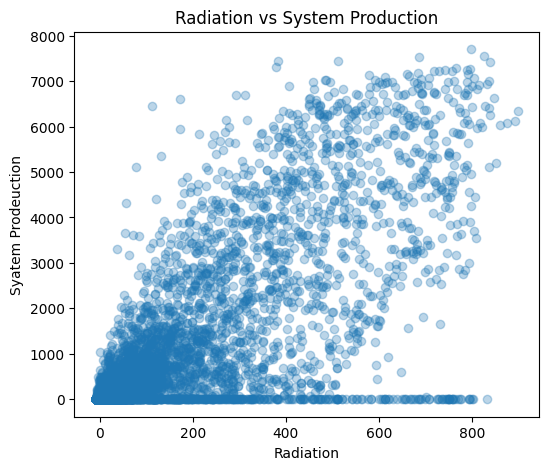

In [12]:
plt.figure(figsize=(6,5))
plt.scatter(df['Radiation'], df['SystemProduction'], alpha=0.3)
plt.xlabel("Radiation")
plt.ylabel('Syatem Prodeuction')
plt.title('Radiation vs System Production')

The relationship between radiation and production is linear, as expected, with a strong vertical spread. That will be due to its dependence on the other weather parameters like temperature effect, wind, cloud etc.

Also, there are many zero production at moderate radiation, that might be due to shading, low panel angle or some data measurement issue.

In [13]:
# Investigate zero production during day time:
anomaly = df[(df['Radiation']> 200) & (df["SystemProduction"]==0)]
print("Number of suspicious points:", len(anomaly))
anomaly.head()

Number of suspicious points: 200


,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
Date-Hour(NMT),,,,,,,
2017-02-12 14:00:00,1.6,60,1042.4,252.7,-2.2,71,0.0
2017-02-12 15:00:00,1.8,60,1042.0,226.2,-2.5,75,0.0
2017-02-13 14:00:00,1.7,60,1038.8,227.9,-1.0,72,0.0
2017-02-14 14:00:00,1.5,60,1035.7,254.3,1.1,70,0.0
2017-02-17 11:00:00,0.4,60,1016.3,203.6,-1.0,90,0.0


Total 200 datapoints have zero production at day time. As we can see clearly, it is happening mostly in witer time(february month and temperature is negative), so this might be due to snow cover of system downtime. lets quatify the impact:

In [14]:
anomaly_percentage = (len(anomaly)/len(df))*100
print("The anomaly percentage is:", anomaly_percentage)

The anomaly percentage is: 2.28310502283105


It is less then 5 We will create anomaly flag to later see if we should include these values while model training or not?

In [15]:
df['Anomaly_Flag'] = 0
df.loc[(df['Radiation'] > 200) & (df['SystemProduction'] == 0), 'Anomaly_Flag'] = 1
df.head()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Anomaly_Flag
Date-Hour(NMT),,,,,,,,
2017-01-01 00:00:00,0.6,0,1003.8,-7.4,0.1,97,0.0,0
2017-01-01 01:00:00,1.7,0,1003.5,-7.4,-0.2,98,0.0,0
2017-01-01 02:00:00,0.6,0,1003.4,-6.7,-1.2,99,0.0,0
2017-01-01 03:00:00,2.4,0,1003.3,-7.2,-1.3,99,0.0,0
2017-01-01 04:00:00,4.0,0,1003.1,-6.3,3.6,67,0.0,0


**Fix negtive radiation value:**
we earlier observed there are negative values of radiation. This is impossible as radiation can not be negative. This might be wrong data collection by sensor (sensor noise0 during night). We will set them to zero


In [16]:
print("negative radiation count:", (df["Radiation"]<0).sum())
print("Percentage of negative values:", ((df["Radiation"]<0).sum())/len(df))

negative radiation count: 4464
Percentage of negative values: 0.5095890410958904


Approximately 50% of radiation values are negative. That makes sense as radiation are low/zero during approx half of the day.

In [17]:
# Set negative radiation to zero:
df.loc[df['Radiation']<0, 'Radiation'] = 0
(df['Radiation']<0).sum()

np.int64(0)

In [18]:
inconsistent = df[(df['Radiation'] == 0) & (df['SystemProduction'] > 0)]
len(inconsistent)

165

In [19]:
inconsistent.head()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Anomaly_Flag
Date-Hour(NMT),,,,,,,,
2017-01-10 15:00:00,3.8,0,1001.1,0.0,1.3,95,11.5000,0
2017-02-28 18:00:00,4.4,0,980.7,0.0,3.0,90,1.8333,0
2017-03-16 18:00:00,4.8,0,1001.8,0.0,6.0,91,94.3333,0
2017-03-26 20:00:00,2.3,0,1020.7,0.0,15.1,48,21.5000,0
2017-03-27 20:00:00,1.4,0,1016.5,0.0,10.9,49,15.8333,0


There are some points, where radiation was negative ene during mid day time. Also, Sunshine is zero as well at that time. This might be sensor error, since we do not have much information about it, and the number of values is also very less as compared to length of dataset, we will keep it as it is.

Now we will check if the production is fillowing seasonal pattern.

C:\Users\deeks\AppData\Local\Temp\ipykernel_23504\1469556747.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prod = df['SystemProduction'].resample('M').mean()


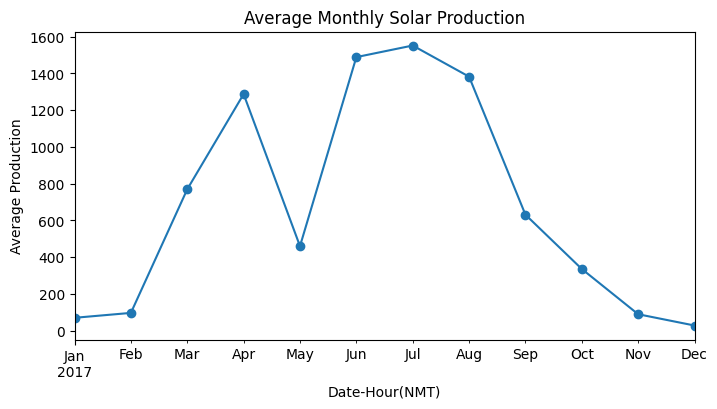

In [20]:
#Plot monthly production variation
monthly_prod = df['SystemProduction'].resample('M').mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
monthly_prod.plot(marker='o')
plt.title("Average Monthly Solar Production")
plt.ylabel("Average Production")
plt.show()

Low production in Jan, Feb, Nov, Dec and high production in other months. May is slightly lower than apr and june.

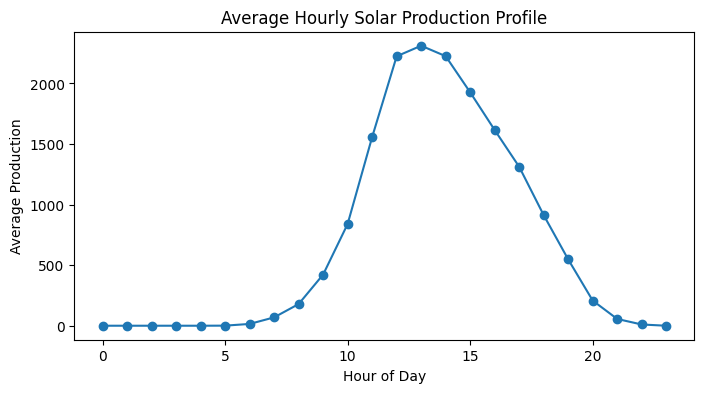

In [21]:
# plot daily production variation:
daily_profile = df.groupby(df.index.hour)["SystemProduction"].mean()

plt.figure(figsize=(8,4))
daily_profile.plot(marker = 'o')
plt.title("Average Hourly Solar Production Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Average Production")
plt.show()

No prooduction from 0 to 5 am, peak at around 12=2 pm, and them productionn gain starts decline.

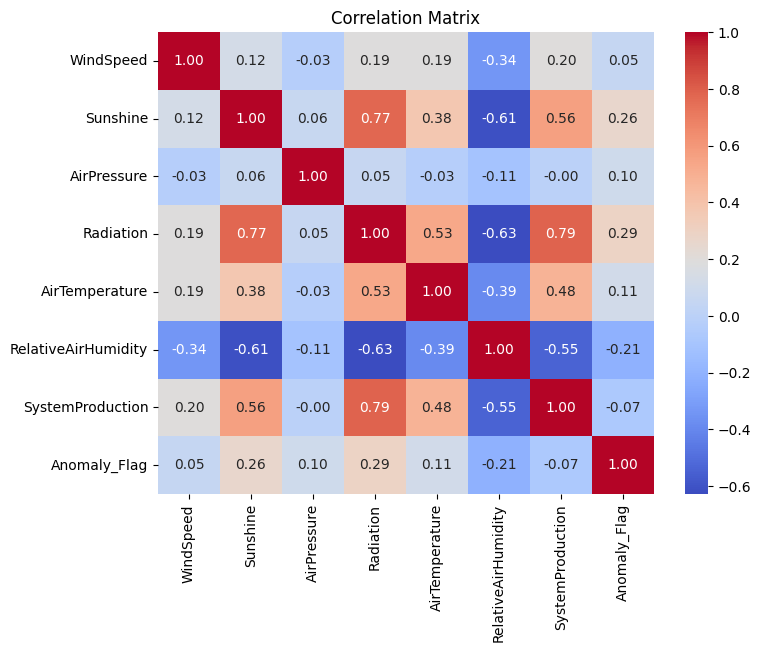

In [22]:
# Understand correlation structire:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Radiation has very strong correlation with Production. Sunshine and Air Temperature has moderate positive correlation. Relative humidity has negative correlation. Air Pressure has minimum impact on System Production.

Radiation and Sunshine are highly correlated. This means they carry overlapping information. Three based moedls can handle it, but linear moedls may suffer from multicollinearuty.

## Feature Engineering

### Cyclic feature:
Solar Power generation follows strong daily and seasonal cycles. To capture these patterns, time based features are created from the timestamp.

Following features are extracted:
- `Hour` - Captures the daily solar production cycle.
- `DayOfYear` - captures seasonal variation across the year
- `Month` - Provides coarse seasonal grouping
- `Weekday` - Included for completeness (may have minor impact).

These features help the model learn periodic patterns in the solar generation.

In [23]:
# Extract the basic time features
df['Hour'] = df.index.hour
df['DayOfYear'] = df.index.dayofyear
df['Month'] = df.index.month
df['Weekday'] = df.index.weekday

df[['Hour', 'DayOfYear', 'Month', 'Weekday']].head()

,Hour,DayOfYear,Month,Weekday
Date-Hour(NMT),,,,
2017-01-01 00:00:00,0,1,1,6
2017-01-01 01:00:00,1,1,1,6
2017-01-01 02:00:00,2,1,1,6
2017-01-01 03:00:00,3,1,1,6
2017-01-01 04:00:00,4,1,1,6


Right now, Hour and DayOfYear are linear. For example, Hour values are from 0 to 23, and they numerically appear far apart, but they are consecutive in time. So we have to make them cyclic. 

The detail about `Cyclic Encodeing of Time Features` is given in this article- https://towardsdatascience.com/is-your-model-time-blind-the-case-for-cyclical-feature-encoding/

In [24]:
# Create cyclic time features:

# Cyclic encoding for hour
df['Hour_sin'] = np.sin(2*np.pi * df['Hour']/24)
df['Hour_cos'] = np.cos(2* np.pi*df['Hour']/24)

# cyclic encoding for Day of Year
df['DOY_sin'] = np.sin(2*np.pi*df['DayOfYear']/365)
df['DOY_cos'] = np.cos(2*np.pi*df['DayOfYear']/365)

df[['Hour_sin', 'Hour_cos', 'DOY_sin', 'DOY_cos']].head()

,Hour_sin,Hour_cos,DOY_sin,DOY_cos
Date-Hour(NMT),,,,
2017-01-01 00:00:00,0.000000,1.000000,0.017213,0.999852
2017-01-01 01:00:00,0.258819,0.965926,0.017213,0.999852
2017-01-01 02:00:00,0.500000,0.866025,0.017213,0.999852
2017-01-01 03:00:00,0.707107,0.707107,0.017213,0.999852
2017-01-01 04:00:00,0.866025,0.500000,0.017213,0.999852


The sin and cosine transformation will alllow preserving periodic relationships such as:

- Hour 23 and Hour 0 being adjacent in time.
- Smooth transition between consecutive hours.

This encoding improves model learning for time-dependent patterns.

### Lag Features:

Solar power generation exhibits strong temporal dependence.
Current production levels are influenced by recent observations
and by patterns from previous days.

To capture this autocorrelation structure, lag features are created:

- **Lag_1** – production from the previous hour (short-term dependency).
- **Lag_24** – production from the same hour on the previous day (daily cycle).
- **Lag_48** – production from the same hour two days earlier (multi-day persistence).

Lag features allow the model to learn temporal memory and improve
day-ahead forecasting accuracy.

In [25]:
# create lag features:

# 1-hour lag
df['Lag1'] = df['SystemProduction'].shift(1)

# 24-hour lag
df['Lag24'] = df['SystemProduction'].shift(24)

# 48-hour lag
df['Lag48'] = df['SystemProduction'].shift(48)

df[['SystemProduction', 'Lag1', 'Lag24', 'Lag48']].head(10)

,SystemProduction,Lag1,Lag24,Lag48
Date-Hour(NMT),,,,
2017-01-01 00:00:00,0.0,NaN,NaN,NaN
2017-01-01 01:00:00,0.0,0.0,NaN,NaN
2017-01-01 02:00:00,0.0,0.0,NaN,NaN
2017-01-01 03:00:00,0.0,0.0,NaN,NaN
2017-01-01 04:00:00,0.0,0.0,NaN,NaN
2017-01-01 05:00:00,0.0,0.0,NaN,NaN
2017-01-01 06:00:00,0.0,0.0,NaN,NaN
2017-01-01 07:00:00,0.0,0.0,NaN,NaN
2017-01-01 08:00:00,0.0,0.0,NaN,NaN


### Rolling Features:

In addition to lag features, rolling statistics are created to capture short-term trends and smoothing effects in solar production.

- **Rolling Mean (6 hours)** captures recent short-term production behavior.
- **Rolling Mean (24 hours)** captures daily production trends.

These features help the model understand recent patterns and improve stability in forecasting. These features are mainly useful for tree based models, Deep learning models oftem don't need manual rolling because they learn trends automatically from sequences.

In [26]:
## Rolling mean features
df['RollMean_6'] = df['SystemProduction'].rolling(window=6).mean()
df['RollMean_24'] = df['SystemProduction'].rolling(window=24).mean()

df[['SystemProduction', 'RollMean_6', 'RollMean_24']].head(10)

,SystemProduction,RollMean_6,RollMean_24
Date-Hour(NMT),,,
2017-01-01 00:00:00,0.0,NaN,NaN
2017-01-01 01:00:00,0.0,NaN,NaN
2017-01-01 02:00:00,0.0,NaN,NaN
2017-01-01 03:00:00,0.0,NaN,NaN
2017-01-01 04:00:00,0.0,NaN,NaN
2017-01-01 05:00:00,0.0,0.0,NaN
2017-01-01 06:00:00,0.0,0.0,NaN
2017-01-01 07:00:00,0.0,0.0,NaN
2017-01-01 08:00:00,0.0,0.0,NaN


In [27]:
df.isna().sum()

WindSpeed               0
Sunshine                0
AirPressure             0
Radiation               0
AirTemperature          0
RelativeAirHumidity     0
SystemProduction        0
Anomaly_Flag            0
Hour                    0
DayOfYear               0
Month                   0
Weekday                 0
Hour_sin                0
Hour_cos                0
DOY_sin                 0
DOY_cos                 0
Lag1                    1
Lag24                  24
Lag48                  48
RollMean_6              5
RollMean_24            23
dtype: int64

### Defining forecasting structure


In [28]:
# create multi-step target:
forecast_horizon = 24

for i in range(1, forecast_horizon+1):
    df[f'Target_t+{i}'] = df['SystemProduction'].shift(-i)

df.head()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Anomaly_Flag,Hour,DayOfYear,...,Target_t+15,Target_t+16,Target_t+17,Target_t+18,Target_t+19,Target_t+20,Target_t+21,Target_t+22,Target_t+23,Target_t+24
Date-Hour(NMT),,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,0.6,0,1003.8,0.0,0.1,97,0.0,0,0,1,...,130.2083,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 01:00:00,1.7,0,1003.5,0.0,-0.2,98,0.0,0,1,1,...,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 02:00:00,0.6,0,1003.4,0.0,-1.2,99,0.0,0,2,1,...,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 03:00:00,2.4,0,1003.3,0.0,-1.3,99,0.0,0,3,1,...,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 04:00:00,4.0,0,1003.1,0.0,3.6,67,0.0,0,4,1,...,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
# Check NaNs in target columns
target_cols = [col for col in df.columns if "Target_t+" in col]

df[target_cols].isna().sum()

Target_t+1      1
Target_t+2      2
Target_t+3      3
Target_t+4      4
Target_t+5      5
Target_t+6      6
Target_t+7      7
Target_t+8      8
Target_t+9      9
Target_t+10    10
Target_t+11    11
Target_t+12    12
Target_t+13    13
Target_t+14    14
Target_t+15    15
Target_t+16    16
Target_t+17    17
Target_t+18    18
Target_t+19    19
Target_t+20    20
Target_t+21    21
Target_t+22    22
Target_t+23    23
Target_t+24    24
dtype: int64

### Handling Missing Values

All lag, rolling, and target features introduce missing values 
at the beginning or end of the dataset.

To ensure full data consistency, missing values are removed 
only after all feature and target engineering steps are completed.

In [30]:
df.tail(10)

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Anomaly_Flag,Hour,DayOfYear,...,Target_t+15,Target_t+16,Target_t+17,Target_t+18,Target_t+19,Target_t+20,Target_t+21,Target_t+22,Target_t+23,Target_t+24
Date-Hour(NMT),,,,,,,,,,,,,,,,,,,,,
2017-12-31 14:00:00,3.7,0,993.6,18.2,-1.8,83,0.0,0,14,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 15:00:00,5.6,0,991.8,7.7,-1.9,84,0.0,0,15,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 16:00:00,5.2,0,991.2,0.0,-2.1,89,0.0,0,16,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 17:00:00,4.1,0,990.1,0.0,-1.4,93,0.0,0,17,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 18:00:00,4.1,0,989.2,0.0,-0.9,94,0.0,0,18,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 19:00:00,4.1,0,988.2,0.0,-0.7,94,0.0,0,19,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 20:00:00,2.1,0,987.3,0.0,-0.3,95,0.0,0,20,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 21:00:00,1.8,0,986.7,0.0,0.2,93,0.0,0,21,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 22:00:00,2.2,0,986.0,0.0,0.3,92,0.0,0,22,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
df1 = df.dropna().copy()

print("Rows before dropping target NaNs:", len(df))
print("Rows after dropping:", len(df1))

Rows before dropping target NaNs: 8760
Rows after dropping: 8688


### Final Dataset Preparation

After creating 24-hour future targets, the last 24 rows contain missing values
because future observations are not available.

These rows are removed to ensure complete feature and target availability.

The dataset is now fully prepared for forecasting model training.

In [32]:
# add year-month column
df1['YearMonth'] = df1.index.to_period('M')
df1[['YearMonth']].head()

,YearMonth
Date-Hour(NMT),
2017-01-03 00:00:00,2017-01
2017-01-03 01:00:00,2017-01
2017-01-03 02:00:00,2017-01
2017-01-03 03:00:00,2017-01
2017-01-03 04:00:00,2017-01


In [33]:
# define feature and target columns:

# target columns:
target_cols = [col for col in df1.columns if 'Target_t+' in col]
target_cols

['Target_t+1',
 'Target_t+2',
 'Target_t+3',
 'Target_t+4',
 'Target_t+5',
 'Target_t+6',
 'Target_t+7',
 'Target_t+8',
 'Target_t+9',
 'Target_t+10',
 'Target_t+11',
 'Target_t+12',
 'Target_t+13',
 'Target_t+14',
 'Target_t+15',
 'Target_t+16',
 'Target_t+17',
 'Target_t+18',
 'Target_t+19',
 'Target_t+20',
 'Target_t+21',
 'Target_t+22',
 'Target_t+23',
 'Target_t+24']

In [34]:
# feature columns:
feature_cols = [col for col in df1.columns if col not in target_cols]
feature_cols = [col for col in feature_cols if col not in ['SystemProduction','YearMonth']]

We have to remove SystemProduction and YearMonth columns from feature columns as system production is our output and YearMonth created for splitting of dataset for train test and validation.

In [35]:
feature_cols

['WindSpeed',
 'Sunshine',
 'AirPressure',
 'Radiation',
 'AirTemperature',
 'RelativeAirHumidity',
 'Anomaly_Flag',
 'Hour',
 'DayOfYear',
 'Month',
 'Weekday',
 'Hour_sin',
 'Hour_cos',
 'DOY_sin',
 'DOY_cos',
 'Lag1',
 'Lag24',
 'Lag48',
 'RollMean_6',
 'RollMean_24']

### Split dataset

For forecasting of power production, the dataset is split chronologically:

- Training set: January–October
- Validation set: November
- Test set: December

This prevents future information leakage and mimics real operational forecasting.

In [36]:
train = df1[df1['YearMonth'] <= '2017-10']
val = df1[df1['YearMonth'] == '2017-11']
test = df1[df1['YearMonth'] == '2017-12']

print("Train size:", train.shape)
print("Validation size:", val.shape)
print("Test size:", test.shape)

Train size: (7248, 46)
Validation size: (720, 46)
Test size: (720, 46)


In [37]:
# create x and y
x_train = train[feature_cols]
y_train = train[target_cols]

x_val = val[feature_cols]
y_val = val[target_cols]

x_test = test[feature_cols]
y_test = test[target_cols]

## Baseline Model

### Persistence Model

The persistence model is a common baseline in solar forecasting.

It assumes that future solar production will be similar to the most recent observed pattern.

For day-ahead forecasting, this means that the production at a given hour tomorrow
is assumed to be equal to the production at the same hour today.

This simple benchmark is widely used to evaluate whether more complex models
provide meaningful improvement.

### Why Use a Baseline Model?

Before building complex forecasting models, it is important to establish a simple reference benchmark.  
The persistence model is widely used in solar forecasting as a baseline because it assumes that future solar production will follow the most recent observed pattern.

For day-ahead forecasting, this means that the production at a given hour tomorrow is assumed to be equal to the production at the same hour today.

This baseline helps evaluate whether more advanced models (statistical, machine learning, or deep learning) provide meaningful improvement.  
If a model cannot outperform persistence, it does not add practical value to the forecasting system.

In [38]:
# Persistence prediction using previous day's production
persistence_pred = test['SystemProduction'].shift(24)

# Remove na values (no previous day available)
persistence_pred = persistence_pred.dropna()

# Align actual values
actual = test['SystemProduction'].iloc[24:]

In [39]:
# evaluate the error:
mae = mean_absolute_error(actual, persistence_pred)
rmse = np.sqrt(mean_squared_error(actual, persistence_pred))


In [40]:
print(f'Persistence MAE: {mae},\nPersistence RMSE: {rmse}')

Persistence MAE: 36.03304698275862,
Persistence RMSE: 154.54637060458637


In [41]:
# Calculate nRMSE Plant capacity approximation (max observed production)
plant_capacity = df['SystemProduction'].max()
nrmse = rmse / plant_capacity
nrmse

np.float64(0.020068350942031733)

In [42]:
print(actual.shape)
print(persistence_pred.shape)

(696,)
(696,)


The persistence model achieves:

- MAE ≈ 36
- RMSE ≈ 154
- nRMSE ≈ 2.0%

This serves as a baseline benchmark.  
All subsequent forecasting models must outperform this naive approach to demonstrate meaningful predictive capability.

### Feature Scaling:

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

## Statistical / Linear Models:

### 1. Linear Regression
Since the forecasting task requires predicting the next 24 hours simultaneously, a multi-output regression approach is used where the model predicts all future horizons at once.

In [44]:
#create linear regression model:
lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)

# Generate prediction:
lr_pred = lr_model.predict(x_val_scaled)

# evaluate model
mae_lr = mean_absolute_error(y_val, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_val, lr_pred))
nrmse_lr = rmse_lr/plant_capacity

print(f'MAE: {mae_lr},\nRMSE: {rmse_lr},\nnRMSE:{nrmse_lr} ')

MAE: 481.14615474748643,
RMSE: 607.7117864491502,
nRMSE:0.0789133601414297 


### 2. Ridge Regression

In [45]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train_scaled, y_train)

# prediction
ridge_pred = ridge_model.predict(x_val_scaled)

In [46]:
mae_ridge = mean_absolute_error(y_val, ridge_pred)
rmse_ridge = np.sqrt(mean_squared_error(y_val, ridge_pred))
nrmse_ridge = rmse_ridge/plant_capacity
print(f'MAE: {mae_ridge},\nRMSE: {rmse_ridge},\nnRMSE:{nrmse_ridge} ')

MAE: 481.0537675037567,
RMSE: 607.5805641095384,
nRMSE:0.07889632049208394 


### 3. ElasticNet Regression

In [47]:
elastic_model = MultiOutputRegressor(ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
elastic_model.fit(x_train_scaled, y_train)

,estimator,ElasticNet(al...ax_iter=10000)
,n_jobs,None
,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,10000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False


In [48]:
elastic_pred = elastic_model.predict(x_val_scaled)

In [49]:
mae_elastic = mean_absolute_error(y_val, elastic_pred)
rmse_elastic = np.sqrt(mean_squared_error(y_val, elastic_pred))
nrmse_elastic = rmse_elastic/plant_capacity
print(f'MAE: {mae_elastic},\nRMSE: {rmse_elastic},\nnRMSE:{nrmse_elastic}')

MAE: 478.0982433407649,
RMSE: 600.054039987868,
nRMSE:0.07791897675469005


## Machine Learninig Models

### 1. Random Forest Regressor
Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions.

In [50]:
rf_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators = 200,
        max_depth = 15,
        random_state = 42,
        n_jobs = -1
    )
)
rf_model.fit(x_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,n_jobs,None
,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [51]:
rf_pred = rf_model.predict(x_val)

In [52]:
# evaluate model
mae_rf = mean_absolute_error(y_val, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_val, rf_pred))
nrmse_rf = rmse_rf/plant_capacity

print(f'MAE: {mae_rf},\nRMSE: {rmse_rf},\nnRMSE:{nrmse_rf}')

MAE: 132.1389745150344,
RMSE: 323.58620467319963,
nRMSE:0.04201872544775998


### 2. Gradient Boosting (XGBoost)
XGBoost (Extreme Gradient Boosting) is a powerful ensemble learning algorithm that builds decision trees sequentially. 
Each new tree attempts to correct the errors made by previous trees.

In [53]:
xgb_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators = 300,
        learning_rate = 0.05,
        max_depth = 6,
        subsample = 0.8,
        colsample_bytree = 0.8,
        random_state = 42,
        n_jobs = -1
    )
)

xgb_model.fit(x_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [54]:
xgb_pred = xgb_model.predict(x_val)

# evaluate model
mae_xgb = mean_absolute_error(y_val, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_val, xgb_pred))
nrmse_xgb = rmse_xgb/plant_capacity


print(f'MAE: {mae_xgb},\nRMSE: {rmse_xgb},\nnRMSE:{nrmse_xgb}')

MAE: 164.03016662597656,
RMSE: 347.6817532780517,
nRMSE:0.04514761112557482


## Deep Learning Models:

### 1. LSTM
Long Short-Term Memory (LSTM) networks are a type of recurrent neural network designed to learn temporal dependencies in sequential data.

Unlike traditional machine learning models that treat observations independently, LSTM models process sequences of past observations to capture time-dependent patterns.

For solar power forecasting, the model uses the previous 24 hours of data to predict the next 24 hours of solar production.

`Importent`: LSTM requires sequence input, right now our data is tabular, so we must reshape it into sequences. Example sequence- Input sequence (past 24 hours) → predict next 24 hours

#### Select Features:
For LSTM, we will typically use raw weather + time features, not lag features.

In [55]:
lstm_features = [
    'Radiation',
    'AirTemperature',
    'RelativeAirHumidity',
    'WindSpeed',
    'Sunshine',
    'Hour_sin',
    'Hour_cos',
    'DOY_sin',
    'DOY_cos'
]

In [56]:
# Scaling Features:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

x_features = df1[lstm_features]
y_target = df1[['SystemProduction']]

x_scaled = feature_scaler.fit_transform(x_features)
y_scaled = target_scaler.fit_transform(y_target)

In [57]:
# create sequences:
seq_len = 24
forecast_horizon = 24

x_seq= [] 
y_seq = []

for i in range(len(x_scaled)-seq_len-forecast_horizon):
    #past 24 hours features
    x_seq.append(x_scaled[i:i+seq_len])
    #next 24 hours features
    y_seq.append(
        y_scaled[i+seq_len:i+seq_len+forecast_horizon]
    )

x_seq = np.array(x_seq)
y_seq = np.array(y_seq)

print(x_seq.shape)
print(y_seq.shape)

(8640, 24, 9)
(8640, 24, 1)


In [58]:
# Split data
train_df = df1[df1['YearMonth']<='2017-10']
val_df = df1[df1['YearMonth']=='2017-11']
test_df = df1[df1['YearMonth']=='2017-12']

train_size = len(train_df)-(seq_len+forecast_horizon)
val_size = len(val_df)-(seq_len+forecast_horizon)

x_train_seq = x_seq[:train_size]
y_train_seq = y_seq[:train_size]

x_val_seq = x_seq[train_size:train_size+val_size]
y_val_seq = y_seq[train_size:train_size+val_size]

x_test_seq = x_seq[train_size+val_size:]
y_test_seq = y_seq[train_size+val_size:]

In [59]:
# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_len, x_train_seq.shape[2])),
    LSTM(32),
    Dense(forecast_horizon)
])

model.compile(
    optimizer='adam',
    loss='mse'
)
model.summary()

C:\python 3.12\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 24, 64)              │          18,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 24)                  │             792 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,152 (125.59 KB)

 Trainable params: 32,152 (125.59 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# Train model
history = model.fit(
    x_train_seq,
    y_train_seq,
    validation_data=(x_val_seq,y_val_seq),
    epochs=20,
    batch_size=32
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 36s 133ms/step - loss: 0.0247 - val_loss: 0.0033
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 38s 170ms/step - loss: 0.0180 - val_loss: 0.0022
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - loss: 0.0161 - val_loss: 0.0021
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - loss: 0.0142 - val_loss: 0.0019
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0135 - val_loss: 0.0019
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 114ms/step - loss: 0.0133 - val_loss: 0.0018
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 105ms/step - loss: 0.0125 - val_loss: 0.0018
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - loss: 0.0119 - val_loss: 0.0018
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0118 - val_loss: 0.0019
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - loss: 0.0114 - val_loss: 0.0018
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 0.0112 - val_loss: 0.0022
Epoch 12/20
225/225 ━━━━━━

In [61]:
#predict
lstm_pred = model.predict(x_val_seq)

# convert the scaled prediction into real units
y_val_real = target_scaler.inverse_transform(
    y_val_seq.reshape(-1,1)
)

pred_real = target_scaler.inverse_transform(lstm_pred.reshape(-1,1)) 

#evaluate
mae_lstm = mean_absolute_error(y_val_real, pred_real)
rmse_lstm = np.sqrt(mean_squared_error(y_val_real, pred_real))
nrmse_lstm = rmse_lstm/plant_capacity

print(f'MAE: {mae_lstm},\nRMSE: {rmse_lstm},\nnRMSE:{nrmse_lstm}')

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
MAE: 159.116338955569,
RMSE: 326.08301028006787,
nRMSE:0.04234294380990363


In [62]:
import pandas as pd

model_results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "ElasticNet",
        "Random Forest",
        "XGBoost",
        "LSTM"
    ],

    "MAE": [
        mae_lr,
        mae_ridge,
        mae_elastic,
        mae_rf,
        mae_xgb,
        mae_lstm
    ],

    "RMSE": [
        rmse_lr,
        rmse_ridge,
        rmse_elastic,
        rmse_rf,
        rmse_xgb,
        rmse_lstm
    ],

    "nRMSE": [
        nrmse_lr,
        nrmse_ridge,
        nrmse_elastic,
        nrmse_rf,
        nrmse_xgb,
        nrmse_lstm
    ]

})

model_results

,Model,MAE,RMSE,nRMSE
0,Linear Regression,481.146155,607.711786,0.078913
1,Ridge Regression,481.053768,607.580564,0.078896
2,ElasticNet,478.098243,600.054040,0.077919
3,Random Forest,132.138975,323.586205,0.042019
4,XGBoost,164.030167,347.681753,0.045148
5,LSTM,159.116339,326.083010,0.042343


### Model Performance Comparison

The results show clear differences between statistical, machine learning, and deep learning models. Linear models (Linear Regression, Ridge, and ElasticNet) produced the highest errors because they assume linear relationships between input variables and solar power output, which is not realistic for weather-driven systems.

Machine learning models significantly improved forecasting performance. Random Forest achieved the best results, indicating that tree-based models are effective at capturing nonlinear relationships between weather variables and solar generation.

The LSTM deep learning model produced performance comparable to Random Forest by learning temporal patterns from sequential data. Overall, the results demonstrate that machine learning and deep learning approaches outperform traditional statistical models for solar power forecasting.

### Key Observations

- Linear regression models performed poorly due to their inability to capture nonlinear relationships.

- Machine learning models significantly reduced prediction error by modeling complex interactions between weather variables.

- Random Forest achieved the best performance among all tested models.

- The LSTM model successfully captured temporal dependencies but did not significantly outperform tree-based models in this dataset.

- This comparison highlights the importance of selecting appropriate modeling techniques for renewable energy forecasting tasks.